$$
w(t) = \left(1 - 2 \pi^2 f_m^2 t^2 \right) e^{- \pi^2 f_m^2 t^2 }
$$





$$
y[n] = \sum_{k \in K} s[k] \cdot w[n - k + c]
$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
fm = 40.0                # central frequency of Ricker (Hz)
Ts = 0.002               # sampling interval (s)
arrival_ms = [100, 160, 220, 280, 340, 400, 460]  # arrival times in ms
fs = 1 / Ts
f_Nyquist = fs / 2
print(f"Sampling frequency: {fs} Hz")
print(f"Nyquist frequency: {f_Nyquist} Hz")
arrival_times = [t/1000.0 for t in arrival_ms]
t_end = arrival_times[-1] + 4.0/fm + 0.05  # extra padding
N = int(np.ceil(t_end / Ts)) + 1
t_out = np.arange(0, N) * Ts
T_wavelet = 4.0 / fm           # total wavelet duration = 4 periods of fm
Lw = int(np.ceil(T_wavelet / Ts))
if Lw % 2 == 0:
    Lw += 1  # make it odd to have a true center
center_idx = Lw // 2
t_wavelet = (np.arange(Lw) - center_idx) * Ts
w = (1 - 2*(np.pi**2)*(fm**2)*(t_wavelet**2)) * np.exp(-(np.pi**2)*(fm**2)*(t_wavelet**2))
print(f"Wavelet length (samples): {Lw}")

Sampling frequency: 500.0 Hz
Nyquist frequency: 250.0 Hz
Wavelet length (samples): 51


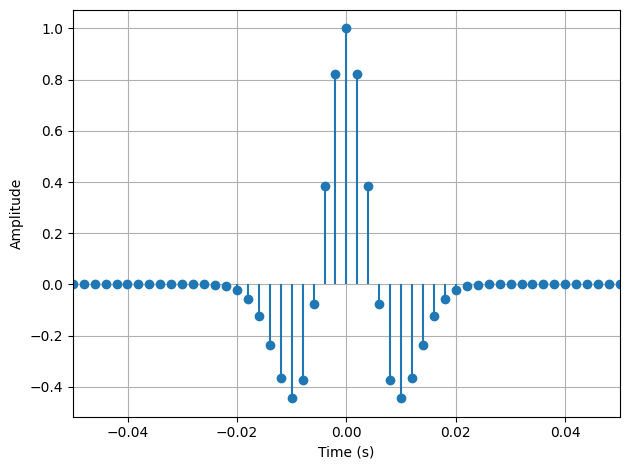

In [3]:
markerline, stemlines, baseline = plt.stem(t_wavelet, w)
baseline.set_visible(False)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.xlim(t_wavelet[0], t_wavelet[-1])
plt.tight_layout()
plt.show()


In [4]:
out_dir = "data/conv_steps_plots"
os.makedirs(out_dir, exist_ok=True)

In [5]:
arrival_times = [t/1000.0 for t in arrival_ms]
t_end = arrival_times[-1] + 4.0/fm + 0.05  # extra padding
N = int(np.ceil(t_end / Ts)) + 1
t_out = np.arange(0, N) * Ts

In [6]:
spike = np.zeros(N)
for t0 in arrival_times:
    idx = int(round(t0 / Ts))
    if 0 <= idx < N:
        spike[idx] += 1.0

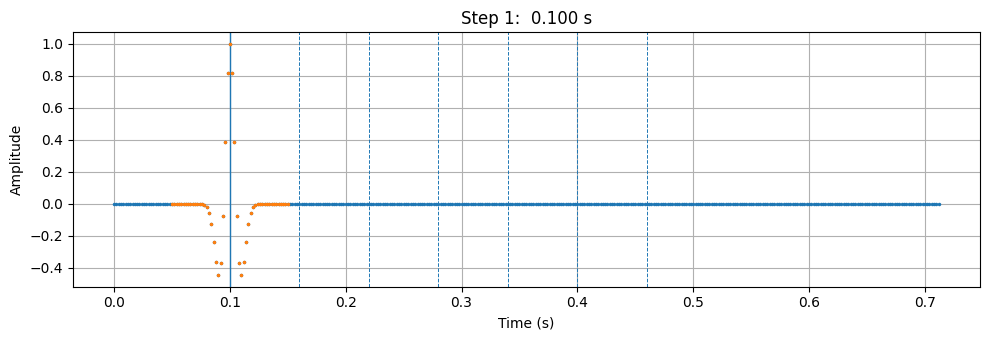

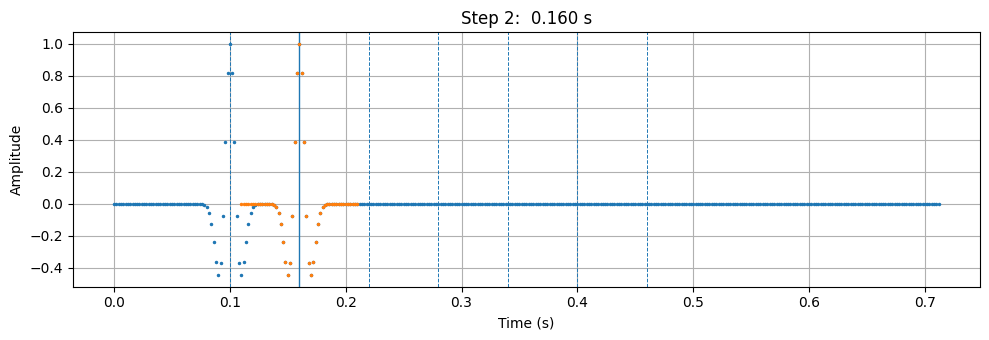

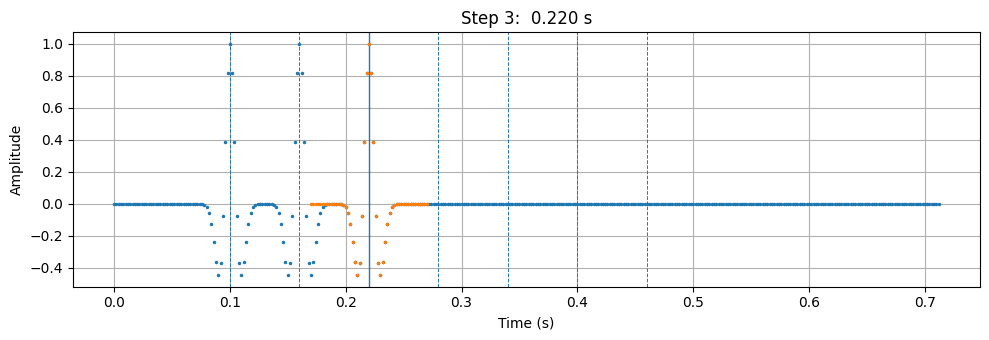

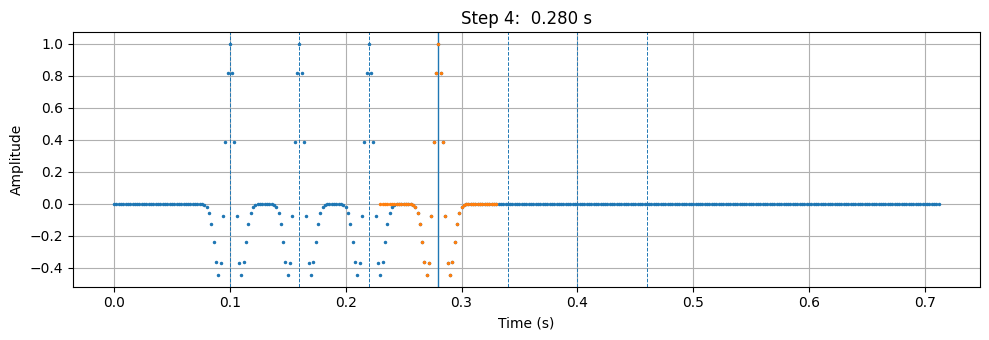

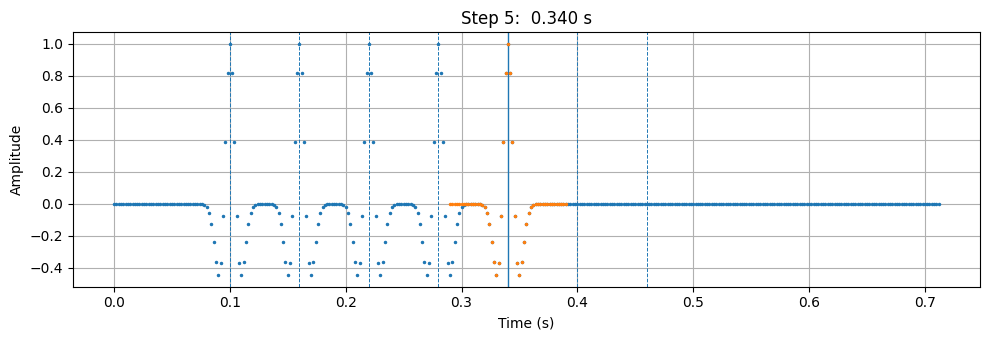

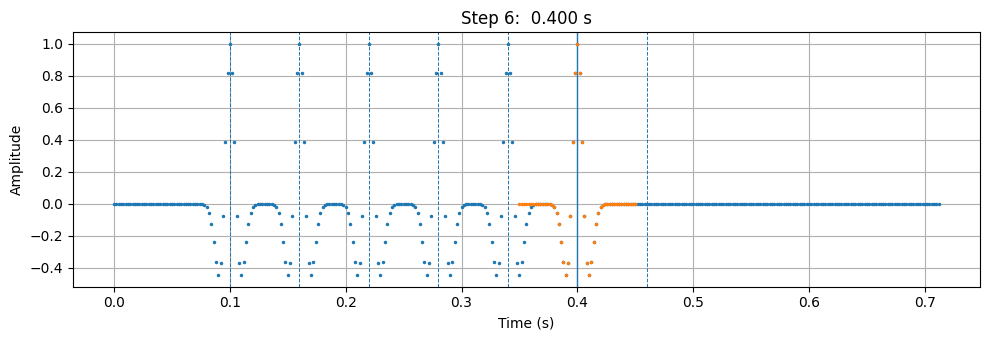

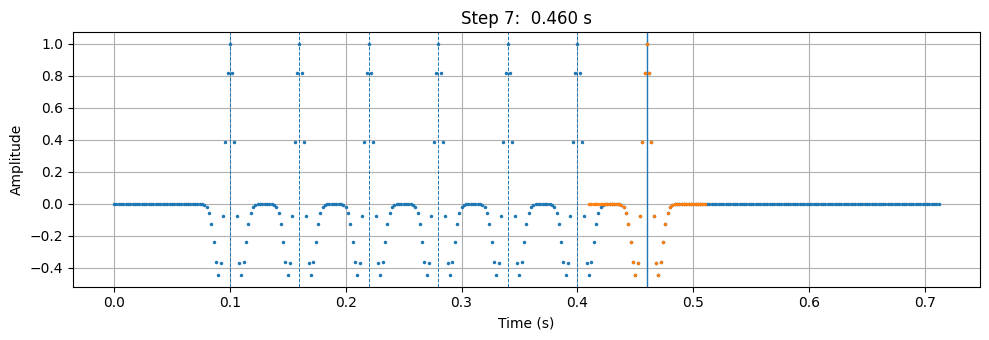

In [7]:
y_len = N + Lw - 1
y = np.zeros(y_len)
nonzero_spike_indices = np.nonzero(spike)[0]
y_steps = []

for step_idx, k in enumerate(nonzero_spike_indices, start=1):
    amp = spike[k]
    start = k - center_idx
    end = start + Lw

    y_start = max(start, 0)
    y_end = min(end, y_len)
    w_start = y_start - start
    w_end = w_start + (y_end - y_start)

    y[y_start:y_end] += amp * w[w_start:w_end]
    y_steps.append(y.copy())
    t_y = np.arange(0, y_len) * Ts
    plt.figure(figsize=(10, 3.5))
    plt.plot(t_y, y, '.', markersize=3, label='Accumulated trace')
    for t0 in arrival_times:
        plt.axvline(t0, linestyle='--', linewidth=0.7)
    curr_arrival = k * Ts
    plt.axvline(curr_arrival, linestyle='-', linewidth=1.0)
    pulse_start_time = start * Ts
    pulse_t = np.arange(pulse_start_time, pulse_start_time + Lw*Ts, Ts)
    plt.plot(pulse_t[w_start:w_end], w[w_start:w_end], '.', markersize=3, label='Recently added pulse')
    plt.title(f'Step {step_idx}:  {curr_arrival:.3f} s')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True)
    plt.tight_layout()

    plot_path = os.path.join(out_dir, f"step_{step_idx:02d}_arrival_{int(arrival_times[step_idx-1]*1000):03d}ms.png")
    plt.savefig(plot_path, dpi=150)
    plt.show()
    plt.close()


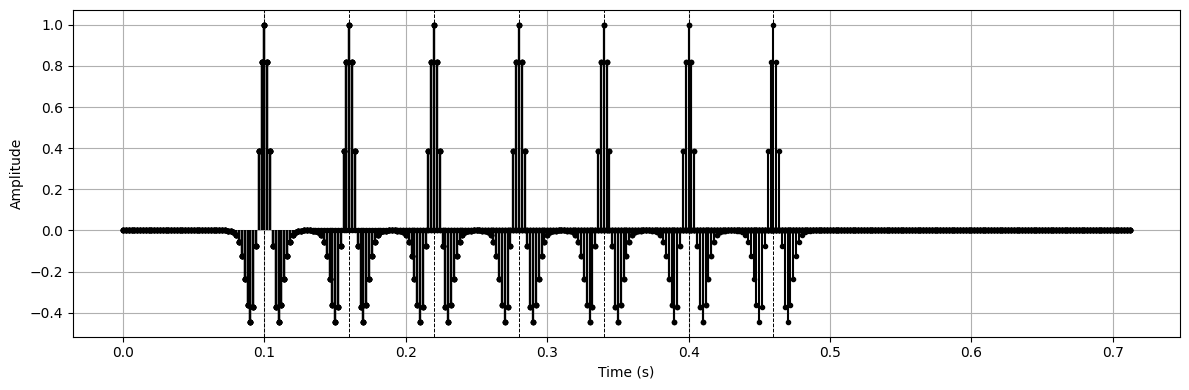

In [8]:
y_len = N + Lw - 1
y = np.zeros(y_len)
nonzero_spike_indices = np.nonzero(spike)[0]
y_steps = []
for step_idx, k in enumerate(nonzero_spike_indices, start=1):
    amp = spike[k]
    start = k - center_idx
    end = start + Lw

    y_start = max(start, 0)
    y_end = min(end, y_len)
    w_start = y_start - start
    w_end = w_start + (y_end - y_start)

    y[y_start:y_end] += amp * w[w_start:w_end]
    y_steps.append(y.copy())

t_y = np.arange(0, y_len) * Ts

plt.figure(figsize=(12, 4))

for y_step in y_steps:
    stem = plt.stem(t_y, y_step, linefmt='k-', markerfmt='ko', basefmt=' ')
    stem.markerline.set_markersize(3)
    stem.stemlines.set_color('black')
    stem.baseline.set_color('black')

for t0 in arrival_times:
    plt.axvline(t0, linestyle='--', color='black', linewidth=0.7)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()


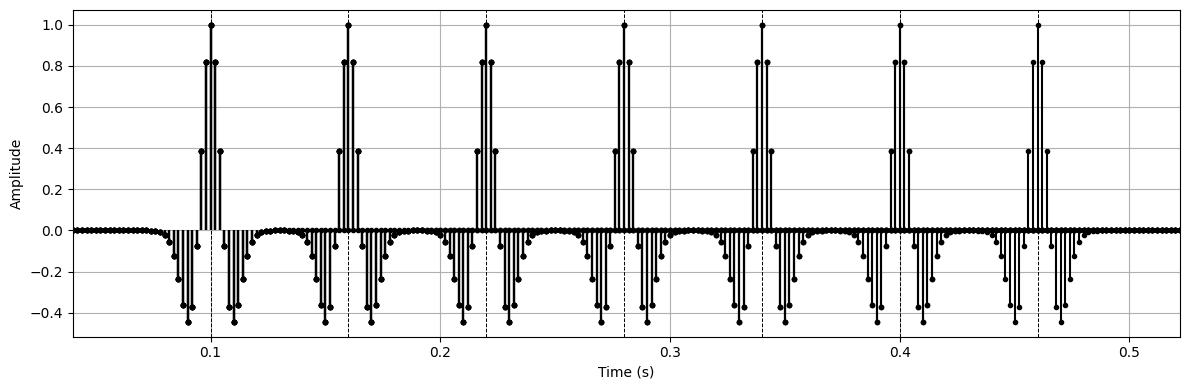

In [9]:
y_len = N + Lw - 1
y = np.zeros(y_len)
nonzero_spike_indices = np.nonzero(spike)[0]
y_steps = []

for step_idx, k in enumerate(nonzero_spike_indices, start=1):
    amp = spike[k]
    start = k - center_idx
    end = start + Lw

    y_start = max(start, 0)
    y_end = min(end, y_len)
    w_start = y_start - start
    w_end = w_start + (y_end - y_start)

    y[y_start:y_end] += amp * w[w_start:w_end]
    y_steps.append(y.copy())

t_y = np.arange(0, y_len) * Ts

plt.figure(figsize=(12, 4))

for y_step in y_steps:
    stem = plt.stem(t_y, y_step, linefmt='k-', markerfmt='ko', basefmt=' ')
    stem.markerline.set_markersize(3)
    stem.stemlines.set_color('black')
    stem.baseline.set_color('black')

for t0 in arrival_times:
    plt.axvline(t0, linestyle='--', color='black', linewidth=0.7)

first_pulse = nonzero_spike_indices[0] - center_idx
last_pulse = nonzero_spike_indices[-1] - center_idx + Lw
x_min = max(0, first_pulse * Ts - 0.01)  
x_max = min(y_len*Ts, last_pulse * Ts + 0.01)  
plt.xlim(x_min, x_max)

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.show()
